In [5]:
import xarray as xr
import numpy as np
from pathlib import Path

#run from the repo root or Scripts directory
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent

#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.tri as tri
import cartopy.feature as cfeature


Read the mean ice-covered days and mesh from `Data/ice_days.nc`.

In [6]:
fn = root / 'Data' / 'ice_days.nc'
with xr.open_dataset(fn, decode_timedelta=False) as ds:
    sic_days_mean = ds['sic_days_mean'].values
    sic_days_masked_mean = ds['sic_days_masked_mean'].values
    plus_days_mean = ds['plus_days_mean'].values
    lat,lon = ds['latitude'].values, ds['longitude'].values
    elements = ds['tri'].values
    display(ds)


<xarray.Dataset> Size: 8MB
Dimensions:               (node: 148406, element: 268590, noel: 3)
Dimensions without coordinates: node, element, noel
Data variables:
    sic_days_mean         (node) float64 1MB 201.9 201.8 202.0 ... 159.4 159.5
    sic_days_masked_mean  (node) float64 1MB 201.9 201.8 202.0 ... 159.4 183.4
    latitude              (node) float32 594kB 69.03 69.03 69.03 ... 66.42 66.42
    longitude             (node) float32 594kB 224.5 224.5 224.6 ... 194.6 194.6
    tri                   (element, noel) int32 3MB 138240 138241 ... 114503
    plus_days_mean        (node) float64 1MB 0.0 0.0 0.0 0.0 ... 30.65 0.0 23.92
Attributes:
    source_years:  1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006...

/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.

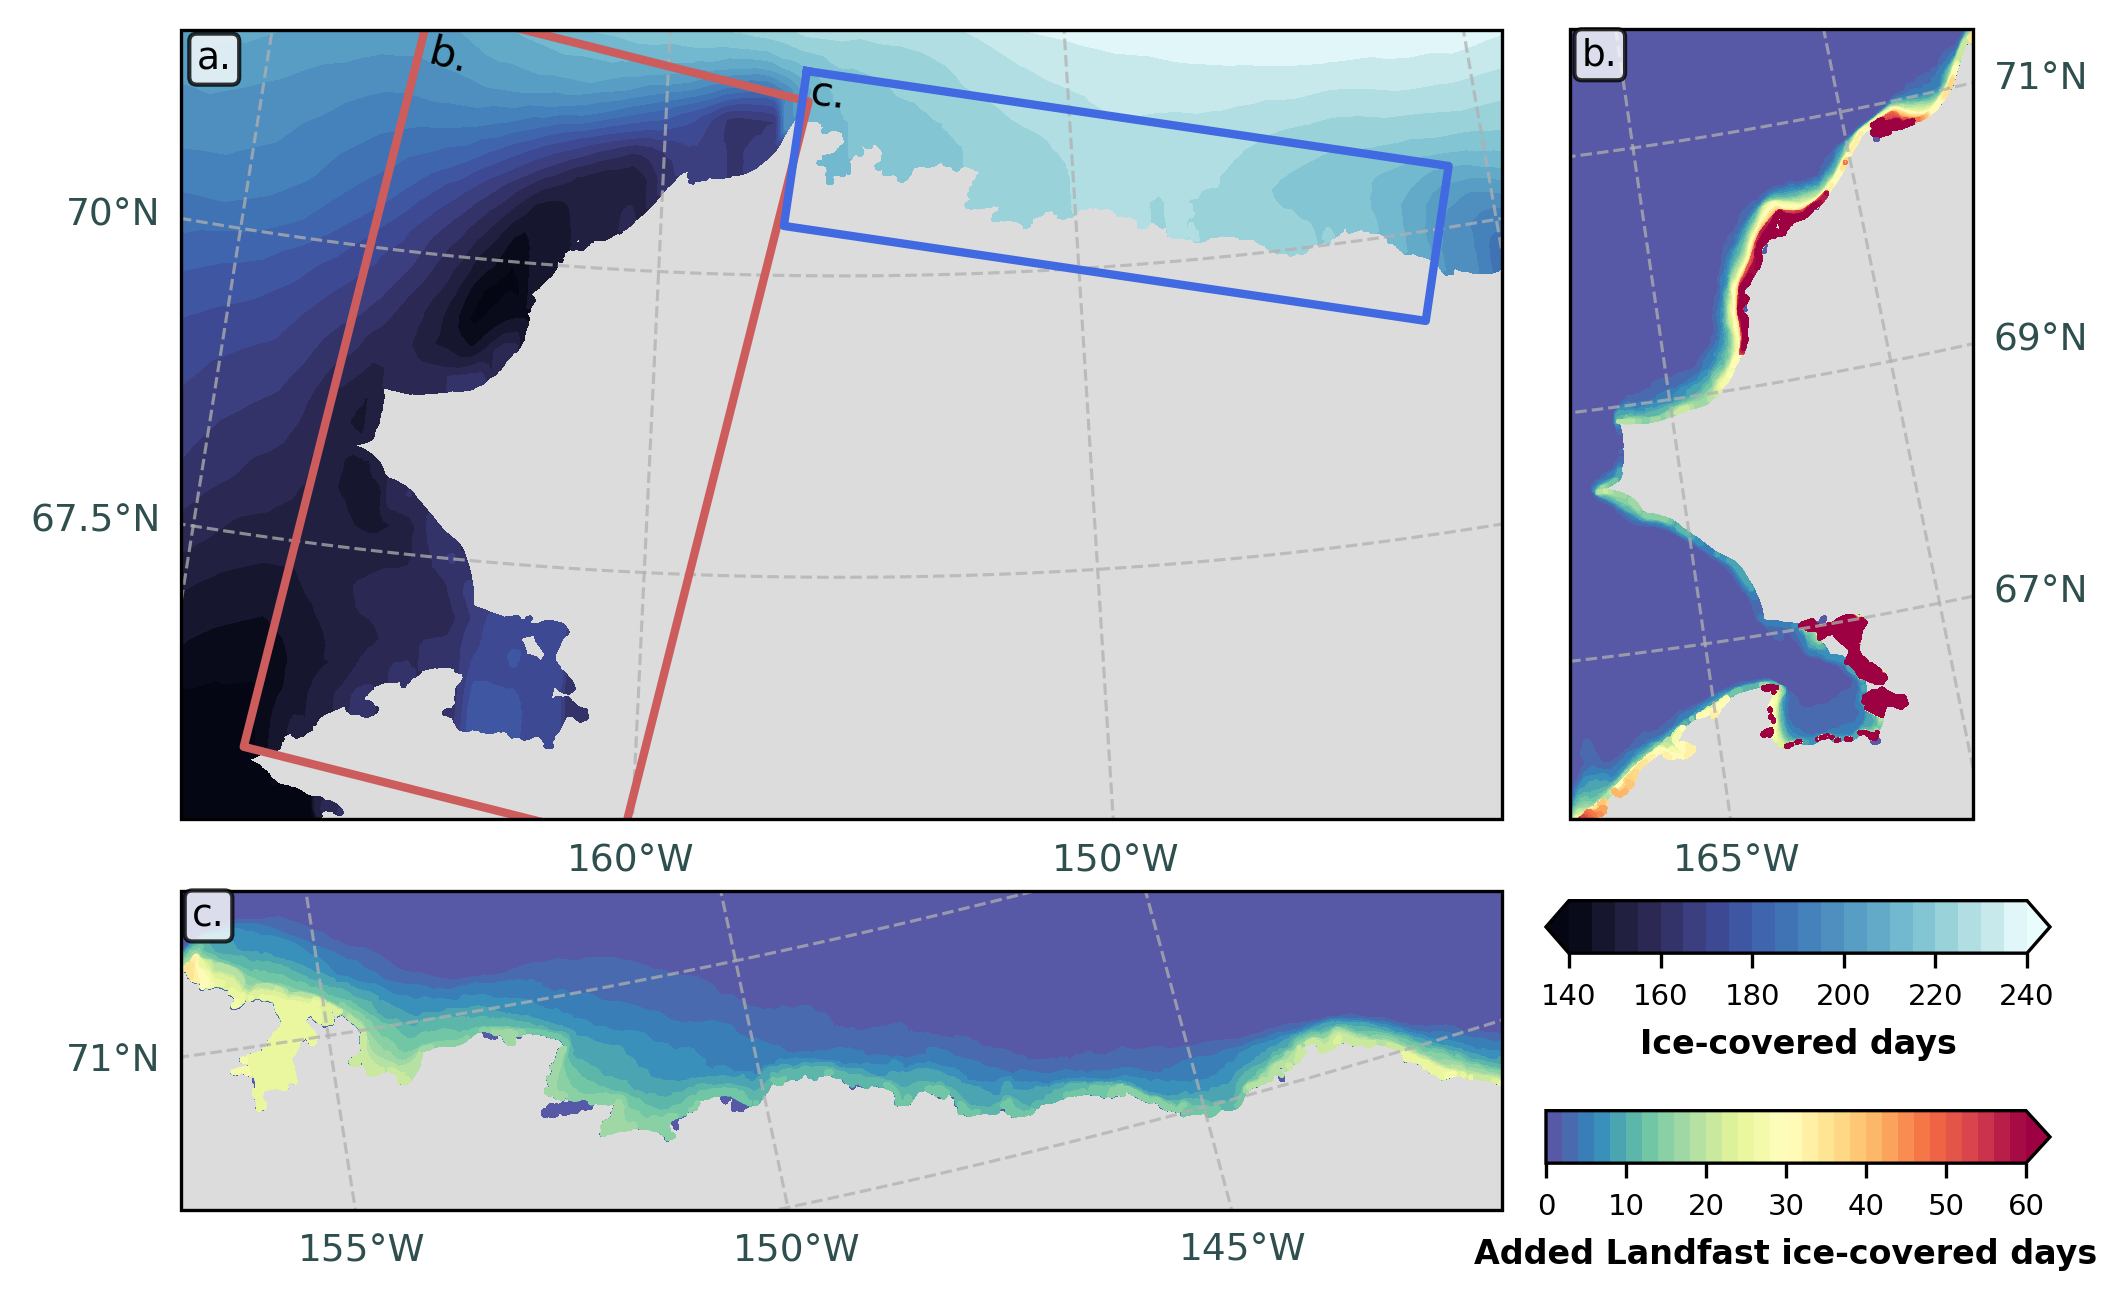

In [7]:
def set_projection(extent, rotation = 0):
    """Set the projection of a Cartopy axis."""
    lon1,lon2,lat1,lat2 = extent[0],extent[1],extent[2],extent[3]
    centlong = (lon1+lon2)/2
    centlat = (lat1+lat2)/2
    proj = ccrs.LambertConformal(central_longitude=centlong+rotation,central_latitude=centlat)
    return proj

def get_axis_boundary_in_lonlat(ax, n_points=100):
    """
    This function gets the boundary of viewable area in a cartopy geoaxes which is projected. 
    
    in:
    ax: geoaxes
    
    out:
    lon and lat arrays meant to be supplied
    """
    #get the limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_min, x_max = xlim
    y_min, y_max = ylim
    
    #create arrays
    top_x = np.linspace(x_min, x_max, n_points)
    top_y = np.full(n_points, y_max)
    right_x = np.full(n_points, x_max)
    right_y = np.linspace(y_max, y_min, n_points)
    bottom_x = np.linspace(x_max, x_min, n_points)
    bottom_y = np.full(n_points, y_min)
    left_x = np.full(n_points, x_min)
    left_y = np.linspace(y_min, y_max, n_points)
    
    #combine
    x_proj = np.concatenate([top_x, right_x, bottom_x, left_x])
    y_proj = np.concatenate([top_y, right_y, bottom_y, left_y])

    #transform
    lon_lat = ccrs.PlateCarree().transform_points(ax.projection, x_proj, y_proj)
    lons = lon_lat[:, 0]
    lats = lon_lat[:, 1]
    
    return lons, lats

def set_triangulation(proj,lon,lat,elements):
    xnew, ynew, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T  #project the lon/lat to the map projection
    triang = tri.Triangulation(xnew,ynew, triangles=elements-1)
    return triang


def make_it_nice(ax,extent,proj):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='gainsboro')
    ax.set_facecolor('gainsboro')

def get_gridlines(ax,region = 'main'):
    if region == 'main':
        xticks = np.arange(-170, 190, 10)
        yticks = np.arange(55, 83, 2.5)
    elif region == 'chukchi':
        xticks = np.arange(-170, -150, 5)
        yticks = np.arange(65, 75, 2)
    elif region == 'beaufort':
        xticks = np.arange(-160, -130, 5)
        yticks = np.arange(67, 73.8, 1)
    else:#raise error
        raise ValueError("Unknown region specified")

    gl = ax.gridlines(draw_labels=True, linestyle='--',
                      xlocs=xticks, ylocs=yticks, alpha=0.75,
                      x_inline=False, y_inline=False,
                      zorder=50, linewidth=0.75,
                      xpadding=10)
    return gl

def add_label(ax, label, dx=0.012,dy=0.98):
    ax.text(dx, dy, label, transform=ax.transAxes, fontsize=9,
         bbox=dict(facecolor='white', edgecolor='black',alpha=0.8, boxstyle='round,pad=0.2'))

def plotboundaryboxes(ax0,lon,lat,label,labellat,labellon,color,rotation=0):
    ax0.plot(lon, lat, color=color, linewidth=2, transform=ccrs.PlateCarree())
    ax0.text(labellon, labellat, label, transform=ccrs.PlateCarree(), fontsize=10,rotation=rotation)

def gl_styler(gl,l=False,r=False,t=False,b=False):
    gl.bottom_labels = b
    gl.top_labels = t
    gl.right_labels = r
    gl.left_labels = l
    gl.xlabel_style = {'size': 9, 'rotation': 0, 'color': 'darkslategrey','ha':'center'}  # <-- Add pad here
    gl.ylabel_style = {'size': 9, 'rotation': 0, 'color': 'darkslategrey'} 

def plot_sic_days(ax,triang,sic_days_mean,levels,cmap):
    cf = ax.tricontourf(triang, sic_days_mean, levels=levels, cmap=cmap,extend = 'both')
    cf.set_edgecolor('face')
    #ax.tricontour(triang, sic_days_mean, levels=levels, colors='white', linewidths=0.2)
    return cf    

def plot_plus_days(ax,triang,plus_days_mean,levels,cmap):
    cf = ax.tricontourf(triang, plus_days_mean, levels=levels, cmap=cmap,extend = 'max')
    cf.set_edgecolor('face')
    #ax.tricontour(triang, plus_days_mean, levels=levels, colors='k', linewidths=0.2)
    return cf


fig = plt.figure(figsize=(14, 14),dpi=300)
gs0 = gridspec.GridSpec(2, 2, figure=fig,width_ratios=[1, 2.52], height_ratios=[1, 5.6],hspace = -0.76,wspace=-0.6)


#First plot covers top row and show general area:
main_extent = [-169.3,-142, 65, 71.65]
main_proj = set_projection(main_extent)
ax0 = fig.add_subplot(gs0[0,0], projection=main_proj)
triang = set_triangulation(main_proj, lon, lat, elements)
sic_levels = np.arange(140, 241, 5)
icecmap = cmocean.cm.ice
cf0 = plot_sic_days(ax0,triang,sic_days_mean,sic_levels,icecmap)
make_it_nice(ax0,main_extent,main_proj)
gl = get_gridlines(ax0,region='main')
gl_styler(gl,l=True,b=True)


plus_levels = np.arange(0, 60.5, 2)
plusmap = sns.color_palette("Spectral_r", as_cmap=True)


#Second plot is chukchi zoom - row 1, col 1
x1,y1 = -166.25, 65.6
x2,y2 = -160, 71.65
chuk_extent = [x1, x2, y1, y2]
chuk_rotation = -15  # Store rotation value
chuk_proj = set_projection(chuk_extent, rotation=chuk_rotation)
triang = set_triangulation(chuk_proj, lon, lat, elements)

ax1 = fig.add_subplot(gs0[0,1], projection=chuk_proj)
make_it_nice(ax1,chuk_extent,chuk_proj)
chuk_lon, chuk_lat = get_axis_boundary_in_lonlat(ax1, n_points=100)

gl = get_gridlines(ax1,region='chukchi')
gl_styler(gl,r=True,b=True)

cf1 = plot_plus_days(ax1,triang,plus_days_mean,plus_levels,plusmap)



#Third plot is Beaufort zoom - row 1, col 1
x1,y1 = -157, 70.4
x2,y2 = -141, 70.5
beau_extent = [x1, x2, y1, y2]
beau_rotation = -20  # Store rotation value
beau_proj = set_projection(beau_extent, rotation=beau_rotation)
triang = set_triangulation(beau_proj, lon, lat, elements)


ax2 = fig.add_subplot(gs0[1,0], projection=beau_proj)

make_it_nice(ax2,beau_extent,beau_proj)
beau_lon, beau_lat = get_axis_boundary_in_lonlat(ax2, n_points=100)
gl = get_gridlines(ax2,region='beaufort')
gl_styler(gl,l=True,b=True)

cf2 = plot_plus_days(ax2,triang,plus_days_mean,plus_levels,plusmap)

#plot the boundary boxes on the main map

    
plotboundaryboxes(ax0,chuk_lon, chuk_lat,'b.',71.45,-166.10,'indianred',rotation=-15)
plotboundaryboxes(ax0,beau_lon, beau_lat,'c.',71.35,-156.5,'royalblue',rotation=-7.5)

add_label(ax0, 'a.',dy = 0.95)
add_label(ax1, 'b.',dx=0.03,dy=0.955)
add_label(ax2, 'c.',dy=0.89,dx=0.0085)


#colorbar setup
xorg,yorg,xlen,ylen = 0.45,0.66,0.12,0.0125

cbar_sic_ax = fig.add_axes([xorg,yorg,xlen,ylen])  # [left, bottom, width, height]
cbar_sic = plt.colorbar(cf0, cax=cbar_sic_ax, orientation='horizontal')
cbar_sic.set_label('Ice-covered days', fontsize=8,fontweight='bold')
ticks_sic = np.arange(140, 250, 20)
cbar_sic.set_ticks(ticks_sic)
cbar_sic.ax.set_xticklabels([str(t) for t in ticks_sic], fontsize=7) 

cbar_plus_ax = fig.add_axes([xorg,yorg-0.05,xlen,ylen])  # [left, bottom, width, height]
cbar_plus = plt.colorbar(cf1, cax=cbar_plus_ax, orientation='horizontal')
cbar_plus.set_label('Added Landfast ice-covered days', fontsize=8,fontweight='bold')
ticks_plus = np.arange(0, 70, 10)
cbar_plus.set_ticks(ticks_plus)
cbar_plus.ax.set_xticklabels([str(t) for t in ticks_plus], fontsize=7)  # Optional: Format tick labels

plt.savefig(root / 'Figures' / 'ice_days.png', bbox_inches='tight', dpi=300)


